In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://pro-api.coinmarketcap.com'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'f2f6372e072f47818bab3d9181f66b66',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video


In [2]:
type(data)

dict

In [3]:
import pandas as pd

#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [4]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,minted_market_cap,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12570,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.999706e+07,1.999706e+07,False,1.376938e+12,NaN,1,NaN,NaN,None,2026-03-03T00:33:00.000Z,68857.035932,5.625929e+10,5.618544e+10,7.385086e+07,38.1176,-0.054100,4.187991,6.201123,-12.821637,-22.418270,-24.399389,1.376938e+12,58.5607,1.445998e+12,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
1,1027,Ethereum,ETH,ethereum,11601,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.206922e+08,1.206922e+08,True,2.447853e+11,NaN,2,NaN,NaN,None,2026-03-03T00:33:00.000Z,2028.178402,2.611026e+10,2.588299e+10,2.272687e+08,10.3333,-0.321957,3.954413,8.875738,-17.466111,-32.478385,-32.140366,2.447853e+11,10.4106,2.447853e+11,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
2,825,Tether USDt,USDT,tether,172235,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.836339e+11,1.879382e+11,True,1.879409e+11,NaN,3,NaN,NaN,None,2026-03-03T00:33:00.000Z,1.000014,1.068994e+11,1.044749e+11,2.424524e+09,27.8601,-0.013037,-0.003208,0.032904,0.070085,0.123655,-0.027926,1.836365e+11,7.8100,1.879409e+11,None,2026-03-03T00:33:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-03-02 19:37:28.384869
3,1839,BNB,BNB,bnb,3138,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",1.363587e+08,1.363587e+08,1.363587e+08,False,8.709485e+10,NaN,4,NaN,NaN,None,2026-03-03T00:34:00.000Z,638.718835,1.917936e+09,1.866031e+09,5.190489e+07,-0.3712,0.069982,3.591520,6.621242,-18.471974,-25.917099,-26.973121,8.709485e+10,3.7041,8.709485e+10,None,2026-03-03T00:34:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
4,52,XRP,XRP,xrp,1804,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,6.109038e+10,9.998571e+10,False,1.385367e+11,NaN,5,NaN,NaN,None,2026-03-03T00:33:00.000Z,1.385565,3.317952e+09,3.314575e+09,3.376737e+06,-0.8993,-0.351742,2.035115,2.194310,-16.751409,-26.147041,-35.366676,8.464471e+10,3.5999,1.385565e+11,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
5,3408,USDC,USDC,usd-coin,37767,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,7.593792e+10,7.593792e+10,False,7.593767e+10,NaN,6,6.090122e+10,6.090102e+10,None,2026-03-03T00:33:00.000Z,0.999997,1.783812e+10,1.435167e+10,3.486452e+09,76.6873,-0.021651,0.002891,0.000850,0.040457,0.014041,0.016019,7.593767e+10,3.2296,7.593767e+10,None,2026-03-03T00:33:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-03-02 19:37:28.384869
6,5426,Solana,SOL,solana,1093,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.696462e+08,6.214645e+08,True,5.375318e+10,NaN,7,5.252369e+08,4.543003e+10,None,2026-03-03T00:33:00.000Z,86.494369,5.470537e+09,5.470505e+09,3.194702e+04,17.9415,-0.490898,3.007309,10.606469,-18.329027,-31.725201,-37.326044,4.927119e+10,2.0955,5.375318e+10,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
7,1958,TRON,TRX,tron,1303,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.474153

In [5]:
def api_runner():
    
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://pro-api.coinmarketcap.com'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': 'f2f6372e072f47818bab3d9181f66b66',
    }
    
    session = Session()
    session.headers.update(headers)
    
    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

    df2 = pd.json_normalize(data['data'])
    df2['timestamp'] = pd.to_datetime('now')
    df_append = pd.DataFrame(df2)
    df = pd.concat([df2,df_append])

# Use this if you want to create a csv and append data to it
#df = pd.json_normalize(data['data'])
#df['timestamp'] = pd.to_datetime('now')
#df

#if not os.path.isfile(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv'):
        #df.to_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv', header='column_names')
    #else:
        #df.to_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv', mode='a', header=False)

# If that didn't work try using the local host URL as shown in the video


In [6]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed successfully')
    sleep(60) #sleep for 1 minute
exit()

API Runner completed successfully
API Runner completed successfully
API Runner completed successfully
API Runner completed successfully


KeyboardInterrupt: 

In [7]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,minted_market_cap,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12570,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.999706e+07,1.999706e+07,False,1.376938e+12,NaN,1,NaN,NaN,None,2026-03-03T00:33:00.000Z,68857.035932,5.625929e+10,5.618544e+10,7.385086e+07,38.1176,-0.054100,4.187991,6.201123,-12.821637,-22.418270,-24.399389,1.376938e+12,58.5607,1.445998e+12,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
1,1027,Ethereum,ETH,ethereum,11601,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.206922e+08,1.206922e+08,True,2.447853e+11,NaN,2,NaN,NaN,None,2026-03-03T00:33:00.000Z,2028.178402,2.611026e+10,2.588299e+10,2.272687e+08,10.3333,-0.321957,3.954413,8.875738,-17.466111,-32.478385,-32.140366,2.447853e+11,10.4106,2.447853e+11,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
2,825,Tether USDt,USDT,tether,172235,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.836339e+11,1.879382e+11,True,1.879409e+11,NaN,3,NaN,NaN,None,2026-03-03T00:33:00.000Z,1.000014,1.068994e+11,1.044749e+11,2.424524e+09,27.8601,-0.013037,-0.003208,0.032904,0.070085,0.123655,-0.027926,1.836365e+11,7.8100,1.879409e+11,None,2026-03-03T00:33:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-03-02 19:37:28.384869
3,1839,BNB,BNB,bnb,3138,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",1.363587e+08,1.363587e+08,1.363587e+08,False,8.709485e+10,NaN,4,NaN,NaN,None,2026-03-03T00:34:00.000Z,638.718835,1.917936e+09,1.866031e+09,5.190489e+07,-0.3712,0.069982,3.591520,6.621242,-18.471974,-25.917099,-26.973121,8.709485e+10,3.7041,8.709485e+10,None,2026-03-03T00:34:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
4,52,XRP,XRP,xrp,1804,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,6.109038e+10,9.998571e+10,False,1.385367e+11,NaN,5,NaN,NaN,None,2026-03-03T00:33:00.000Z,1.385565,3.317952e+09,3.314575e+09,3.376737e+06,-0.8993,-0.351742,2.035115,2.194310,-16.751409,-26.147041,-35.366676,8.464471e+10,3.5999,1.385565e+11,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
5,3408,USDC,USDC,usd-coin,37767,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,7.593792e+10,7.593792e+10,False,7.593767e+10,NaN,6,6.090122e+10,6.090102e+10,None,2026-03-03T00:33:00.000Z,0.999997,1.783812e+10,1.435167e+10,3.486452e+09,76.6873,-0.021651,0.002891,0.000850,0.040457,0.014041,0.016019,7.593767e+10,3.2296,7.593767e+10,None,2026-03-03T00:33:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-03-02 19:37:28.384869
6,5426,Solana,SOL,solana,1093,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.696462e+08,6.214645e+08,True,5.375318e+10,NaN,7,5.252369e+08,4.543003e+10,None,2026-03-03T00:33:00.000Z,86.494369,5.470537e+09,5.470505e+09,3.194702e+04,17.9415,-0.490898,3.007309,10.606469,-18.329027,-31.725201,-37.326044,4.927119e+10,2.0955,5.375318e+10,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
7,1958,TRON,TRX,tron,1303,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.474153

In [8]:
# One thing I noticed was the scientific notation. I like it, but I want to be able to see the numbers in this case

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [9]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,minted_market_cap,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12570,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",21000000.00000,19997062.00000,19997062.00000,False,1376938416666.66992,NaN,1,NaN,NaN,None,2026-03-03T00:33:00.000Z,68857.03593,56259286414.66379,56185435553.83453,73850860.82925,38.11760,-0.05410,4.18799,6.20112,-12.82164,-22.41827,-24.39939,1376938416666.66772,58.56070,1445997754570.14990,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
1,1027,Ethereum,ETH,ethereum,11601,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,120692217.57655,120692217.57655,True,244785348921.64999,NaN,2,NaN,NaN,None,2026-03-03T00:33:00.000Z,2028.17840,26110261237.80041,25882992505.35823,227268732.44215,10.33330,-0.32196,3.95441,8.87574,-17.46611,-32.47838,-32.14037,244785348921.64529,10.41060,244785348921.64999,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
2,825,Tether USDt,USDT,tether,172235,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,183633868264.82590,187938184844.71698,True,187940863651.48001,NaN,3,NaN,NaN,None,2026-03-03T00:33:00.000Z,1.00001,106899446240.03413,104474922580.46498,2424523659.56929,27.86010,-0.01304,-0.00321,0.03290,0.07009,0.12365,-0.02793,183636485719.32727,7.81000,187940863651.48001,None,2026-03-03T00:33:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-03-02 19:37:28.384869
3,1839,BNB,BNB,bnb,3138,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",136358663.18000,136358663.18000,136358663.18000,False,87094846423.84000,NaN,4,NaN,NaN,None,2026-03-03T00:34:00.000Z,638.71883,1917935820.43984,1866030933.33239,51904887.10745,-0.37120,0.06998,3.59152,6.62124,-18.47197,-25.91710,-26.97312,87094846423.84428,3.70410,87094846423.84000,None,2026-03-03T00:34:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
4,52,XRP,XRP,xrp,1804,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",100000000000.00000,61090376977.00000,99985708785.00000,False,138536737132.89001,NaN,5,NaN,NaN,None,2026-03-03T00:33:00.000Z,1.38557,3317951992.40035,3314575255.56162,3376736.83872,-0.89930,-0.35174,2.03512,2.19431,-16.75141,-26.14704,-35.36668,84644711723.85829,3.59990,138556538545.70999,None,2026-03-03T00:33:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-03-02 19:37:28.384869
5,3408,USDC,USDC,usd-coin,37767,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,75937924827.70428,75937924827.70428,False,75937672035.03000,NaN,6,60901219650.23000,60901016913.82281,None,2026-03-03T00:33:00.000Z,1.00000,17838122813.84932,14351670420.49374,3486452393.35553,76.68730,-0.02165,0.00289,0.00085,0.04046,0.01404,0.01602,75937672035.03218,3.22960,75937672035.03000,None,2026-03-03T00:33:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-03-02 19:37:28.384869
6,5426,Solana,SOL,solana,1093,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,569646230.75176,621464542.02966,True,53753183684.95000,NaN,7,525236893.30000,45430033886.50503,None,2026-03-03T00:33:00.000Z,86.49437,5470537254.88217,5470505307.85763,31947.02454,17.94150,-0.49090,3.00731,10.60647,-18.32903,

In [16]:
# Now let's look at the coin trends over time

df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.05410,4.18799,6.20112,-12.82164,-22.41827,-24.39939
Ethereum,-0.32196,3.95441,8.87574,-17.46611,-32.47838,-32.14037
Tether USDt,-0.01304,-0.00321,0.03290,0.07009,0.12365,-0.02793
BNB,0.06998,3.59152,6.62124,-18.47197,-25.91710,-26.97312
XRP,-0.35174,2.03512,2.19431,-16.75141,-26.14704,-35.36668
USDC,-0.02165,0.00289,0.00085,0.04046,0.01404,0.01602
Solana,-0.49090,3.00731,10.60647,-18.32903,-31.72520,-37.32604
TRON,0.00700,0.85953,0.62934,-0.98509,-1.20657,0.83016
Dogecoin,-0.30616,0.92620,0.14115,-11.08390,-26.10867,-35.90262


In [17]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.05410
              quote.USD.percent_change_24h     4.18799
              quote.USD.percent_change_7d      6.20112
              quote.USD.percent_change_30d   -12.82164
              quote.USD.percent_change_60d   -22.41827
              quote.USD.percent_change_90d   -24.39939
Ethereum      quote.USD.percent_change_1h     -0.32196
              quote.USD.percent_change_24h     3.95441
              quote.USD.percent_change_7d      8.87574
              quote.USD.percent_change_30d   -17.46611
              quote.USD.percent_change_60d   -32.47838
              quote.USD.percent_change_90d   -32.14037
Tether USDt   quote.USD.percent_change_1h     -0.01304
              quote.USD.percent_change_24h    -0.00321
              quote.USD.percent_change_7d      0.03290
              quote.USD.percent_change_30d     0.07009
              quote.USD.percent_change_60d     0.12365
              quote.US

In [18]:
type(df4)

pandas.core.series.Series

In [20]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.05410
             quote.USD.percent_change_24h   4.18799
             quote.USD.percent_change_7d    6.20112
             quote.USD.percent_change_30d -12.82164
             quote.USD.percent_change_60d -22.41827
             quote.USD.percent_change_90d -24.39939
Ethereum     quote.USD.percent_change_1h   -0.32196
             quote.USD.percent_change_24h   3.95441
             quote.USD.percent_change_7d    8.87574
             quote.USD.percent_change_30d -17.46611
             quote.USD.percent_change_60d -32.47838
             quote.USD.percent_change_90d -32.14037
Tether USDt  quote.USD.percent_change_1h   -0.01304
             quote.USD.percent_change_24h  -0.00321
             quote.USD.percent_change_7d    0.03290
             quote.USD.percent_change_30d   0.07009
             quote.USD.percent_change_60d   0.12365
             quote.USD.percent_change_90d  -0.02793
BNB          quote.USD.percent_change_1h    0.06998
             quote.USD.percent_change_24h   3.59152
             quote.USD.percent_change_7d    6.62124
             quote.USD.percent_change_30d -18.47197
             quote.USD.percent_change_60d -25.91710
             quote.USD.percent_change_90d -26.97312
XRP          quote.USD.percent_change_1h   -0.35174
             quote.USD.percent_change_24h   2.03512
             quote.USD.percent_change_7d    2.19431
             quote.USD.percent_change_30d -16.75141
             quote.USD.percent_change_60d -26.14704
             quote.USD.percent_change_90d -35.36668
USDC         quote.USD.percent_change_1h   -0.02165
             quote.USD.percent_change_24h   0.00289
             quote.USD.percent_change_7d    0.00085
             quote.USD.percent_change_30d   0.04046
             quote.USD.percent_change_60d   0.01404
             quote.USD.percent_change_90d   0.01602
Solana       quote.USD.percent_change_1h   -0.49090
             quote.USD.percent_change_24h   3.00731
             quote.USD.percent_change_7d   10.60647
             quote.USD.percent_change_30d -18.32903
             quote.USD.percent_change_60d -31.72520
             quote.USD.percent_change_90d -37.32604
TRON         quote.USD.percent_change_1h    0.00700
             quote.USD.percent_change_24h   0.85953
             quote.USD.percent_change_7d    0.62934
             quote.USD.percent_change_30d  -0.98509
             quote.USD.percent_change_60d  -1.20657
             quote.USD.percent_change_90d   0.83016
Dogecoin     quote.USD.percent_change_1h   -0.30616
             quote.USD.percent_change_24h   0.92620
             quote.USD.percent_change_7d    0.14115
             quote.USD.percent_change_30d -11.08390
             quote.USD.percent_change_60d -26.10867
             quote.USD.percent_change_90d -35.90262
Cardano      quote.USD.percent_change_1h   -0.88933
             quote.USD.percent_change_24h   0.43904
             quote.USD.percent_change_7d    4.14658
             quote.USD.percent_change_30d  -6.97073
             quote.USD.percent_change_60d -22.76584
             quote.USD.percent_change_90d -36.21063
Bitcoin Cash quote.USD.percent_change_1h    0.45134
             quote.USD.percent_change_24h   0.61520
             quote.USD.percent_change_7d   -9.86393
             quote.USD.percent_change_30d -12.89795
             quote.USD.percent_change_60d -24.53370
             quote.USD.percent_change_90d -18.09094
Hyperliquid  quote.USD.percent_change_1h   -2.18242
             quote.USD.percent_change_24h  -0.30410
             quote.USD.percent_change_7d   22.22601
             quote.USD.percent_change_30d   0.71584
             quote.USD.percent_change_60d  33.00575
             quote.USD.percent_change_90d  -3.73641
UNUS SED LEO quote.USD.percent_change_1h    0.04315
             quote.USD.percent_change_24h  -0.43537
             quote.USD.percent_change_7d   12.67965
             quote.USD.percent_change_30d

In [26]:
df5.count()

values    90
dtype: int64

In [30]:
#Because of how it's structured above we need to set an index. I don't want to pass a column as an index for this dataframe
#So I'm going to create a range and pass that as the dataframe. You can make this more dynamic, but I'm just going to hard code it

index = pd.Index(range(90))

df6 = df5.reset_index()
df6

# If it only has the index and values try doing reset_index like "df5.reset_index()"

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.05410
1,Bitcoin,quote.USD.percent_change_24h,4.18799
2,Bitcoin,quote.USD.percent_change_7d,6.20112
3,Bitcoin,quote.USD.percent_change_30d,-12.82164
4,Bitcoin,quote.USD.percent_change_60d,-22.41827
5,Bitcoin,quote.USD.percent_change_90d,-24.39939
6,Ethereum,quote.USD.percent_change_1h,-0.32196
7,Ethereum,quote.USD.percent_change_24h,3.95441
8,Ethereum,quote.USD.percent_change_7d,8.87574
9,Ethereum,quote.USD.percent_change_30d,-17.46611


In [32]:
# Change the column name
df7 = df6.rename(columns={'level_1':'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.05410
1,Bitcoin,quote.USD.percent_change_24h,4.18799
2,Bitcoin,quote.USD.percent_change_7d,6.20112
3,Bitcoin,quote.USD.percent_change_30d,-12.82164
4,Bitcoin,quote.USD.percent_change_60d,-22.41827
5,Bitcoin,quote.USD.percent_change_90d,-24.39939
6,Ethereum,quote.USD.percent_change_1h,-0.32196
7,Ethereum,quote.USD.percent_change_24h,3.95441
8,Ethereum,quote.USD.percent_change_7d,8.87574
9,Ethereum,quote.USD.percent_change_30d,-17.46611


In [40]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,-0.05410
1,Bitcoin,24h,4.18799
2,Bitcoin,7d,6.20112
3,Bitcoin,30d,-12.82164
4,Bitcoin,60d,-22.41827
5,Bitcoin,90d,-24.39939
6,Ethereum,1h,-0.32196
7,Ethereum,24h,3.95441
8,Ethereum,7d,8.87574
9,Ethereum,30d,-17.46611


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

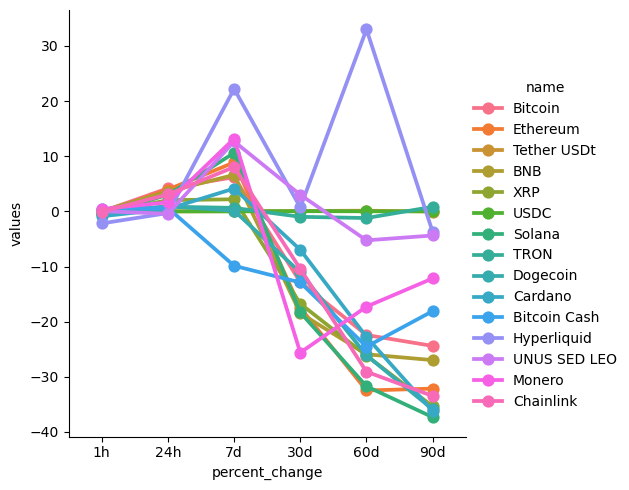

In [42]:
sns.catplot(x='percent_change', y='values',hue='name',data=df7,kind='point')

In [51]:
# we are going to create a dataframe with the columns we want
df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,68857.03593,2026-03-02 19:37:28.384869


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

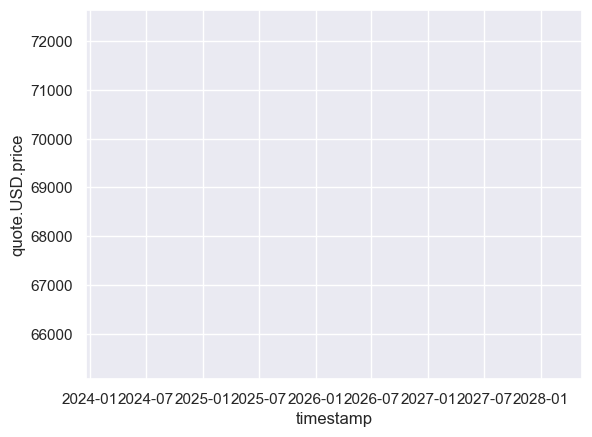

In [50]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)